## Train a Multimodal Hybrid CNN + Landmark Transformer on 100-Driver Dataset (v3)

**Architecture:** MobileNetV3-Large backbone (9 spatial tokens) + face-focused geometric features + lightweight transformer fusion.

**Key fixes over v2:** Stronger backbone, heavier regularization (dropout 0.35, weight decay 5e-2), class-weighted loss, MixUp augmentation, early stopping, reduced transformer capacity, face-centric geometric features with validity gating.

## 0) Install packages

In [1]:
# %pip install -U pip setuptools wheel
# %pip install torch torchvision --index-url https://download.pytorch.org/whl/cu130
# %pip install numpy pandas scikit-learn pillow tqdm matplotlib

## 1) Imports

In [2]:
import os
import json
import math
import random
import time
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Optional

import numpy as np
import pandas as pd
from PIL import Image, ImageFile

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights

ImageFile.LOAD_TRUNCATED_IMAGES = True

/home/lurpd/DevelopmentWSL2/DistractionAI/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2) Config

In [ ]:
DATA_ROOT = Path(r"../../Datasets/100-driver")
SETTING = "Traditional-setting"
TIME_OF_DAY = "Day"
CAMERA = "Cam1"
SPLIT_PREFIX = None
IMG_ROOT_OVERRIDE = None
LANDMARK_PATH_OVERRIDE = None

@dataclass
class TrainConfig:
    #Training
    epochs: int = 80
    backbone_lr: float = 5e-5
    head_lr: float = 5e-4
    weight_decay: float = 5e-2 
    batch_size: int = 32
    num_workers: int = 10
    img_size: int = 224
    warm_epochs: int = 5
    save_every: int = 20
    seed: int = 42
    patience: int = 15  

    #Transformer
    embed_dim: int = 96  
    num_heads: int = 4
    num_layers: int = 3 
    ff_dim: int = 256   
    dropout: float = 0.35  

    #MixUp
    mixup_alpha: float = 0.1

    #Landmark config
    pose_points: int = 33
    hand_points: int = 21
    face_points: int = 478
    landmark_dims: int = 3

    #Geometric features: 10 face + 7 pose + 6 hand = 23 total
    num_geo_features: int = 23

    out_dir: Path = Path(f"../best_models/100-driver/multimodal_v3/{CAMERA}_{TIME_OF_DAY}")
    best_name: str = f"hybrid_transformer_v3_100driver_{CAMERA}_{TIME_OF_DAY}_best.pt"

cfg = TrainConfig()
cfg.out_dir.mkdir(parents=True, exist_ok=True)
print("Config:", cfg)

Config: TrainConfig(epochs=80, backbone_lr=5e-05, head_lr=0.0005, weight_decay=0.05, batch_size=32, num_workers=10, img_size=224, warm_epochs=5, save_every=20, seed=42, patience=15, embed_dim=96, num_heads=4, num_layers=3, ff_dim=256, dropout=0.35, mixup_alpha=0.2, pose_points=33, hand_points=21, face_points=478, landmark_dims=3, num_geo_features=23, out_dir=PosixPath('../best_models/100-driver/multimodal_v3/Cam1_Day'), best_name='hybrid_transformer_v3_100driver_Cam1_Day_best.pt')


## 3) Utils

In [4]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

def cuda_sanity_check():
    print("torch:", torch.__version__)
    try:
        import torchvision
        print("torchvision:", torchvision.__version__)
    except Exception as e:
        print("torchvision import failed:", e)
    print("torch.version.cuda:", torch.version.cuda)
    print("CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        idx = torch.cuda.current_device()
        props = torch.cuda.get_device_properties(idx)
        print("GPU:", props.name)
        print("Total VRAM (GB):", round(props.total_memory / (1024**3), 2))

def parse_split_file(txt_path: Path):
    records = []
    with open(txt_path, "r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 3:
                continue
            records.append({"sample_id": parts[0], "rel_path": parts[1], "label": int(parts[2])})
    return records

def infer_class_names(records):
    names_by_label = defaultdict(list)
    for rec in records:
        rel = Path(rec["rel_path"])
        folder_name = rel.parent.name if rel.parent.name else f"class_{rec['label']}"
        names_by_label[rec["label"]].append(folder_name)
    max_label = max(r["label"] for r in records)
    ordered_names = []
    for i in range(max_label + 1):
        if i in names_by_label:
            ordered_names.append(Counter(names_by_label[i]).most_common(1)[0][0])
        else:
            ordered_names.append(f"class_{i}")
    return ordered_names

def normalize_lookup_key(value):
    if value is None:
        return None
    text = str(value).strip()
    return text.replace("\\", "/") if text else None

def register_entry(lookup, key, entry):
    norm = normalize_lookup_key(key)
    if norm is None:
        return
    lookup.setdefault(norm, entry)
    p = Path(norm)
    lookup.setdefault(p.as_posix(), entry)
    lookup.setdefault(p.name, entry)
    lookup.setdefault(p.stem, entry)

def load_landmark_lookup(landmark_path):
    if landmark_path is None or not Path(landmark_path).exists():
        return {}
    with open(landmark_path, "r", encoding="utf-8") as f:
        raw = json.load(f)
    lookup = {}
    if isinstance(raw, dict):
        if all(isinstance(v, dict) for v in raw.values()):
            for key, value in raw.items():
                register_entry(lookup, key, value)
                if isinstance(value, dict):
                    for ek in ("rel_path","image_path","img_path","path","sample_id","id","file_name","filename"):
                        register_entry(lookup, value.get(ek), value)
    elif isinstance(raw, list):
        for item in raw:
            if not isinstance(item, dict):
                continue
            for ek in ("rel_path","image_path","img_path","path","sample_id","id","file_name","filename"):
                register_entry(lookup, item.get(ek), item)
    return lookup

def resolve_landmark_path(override_path, data_root, time_of_day, camera):
    candidates = []
    if override_path:
        candidates.append(Path(override_path))
    cl = camera.lower(); tl = time_of_day.lower()
    candidates.extend([
        data_root / f"driver_landmarks_{tl}_{cl}.json",
        data_root / f"driver_landmarks_{tl}_{camera}.json",
        data_root / f"driver_landmarks_{cl}_{tl}.json",
        data_root / f"driver_landmarks_{tl}.json",
        data_root / "driver_landmarks.json",
    ])
    for c in candidates:
        if c.exists():
            return c
    return None

seed_everything(cfg.seed)
cuda_sanity_check()

torch: 2.10.0+cu130
torchvision: 0.25.0+cu130
torch.version.cuda: 13.0
CUDA available: True
GPU: NVIDIA GeForce RTX 5070
Total VRAM (GB): 11.94


## 4) Parse split files and define training directories

In [5]:
split_root = DATA_ROOT / "data-splits" / "data-splits" / SETTING / TIME_OF_DAY / CAMERA

if SPLIT_PREFIX is not None:
    prefix = SPLIT_PREFIX
elif SETTING.lower() == "traditional-setting":
    prefix = TIME_OF_DAY[0] + CAMERA[len(CAMERA) - 1]
else:
    raise ValueError("Set SPLIT_PREFIX explicitly for non-traditional settings.")

train_file = prefix + "_train.txt"
val_file = prefix + "_val.txt"
test_file = prefix + "_test.txt"
TRAIN_TXT = split_root / train_file
VAL_TXT = split_root / val_file
TEST_TXT = split_root / test_file

print("Train split:", TRAIN_TXT)
print("Val split:  ", VAL_TXT)
print("Test split: ", TEST_TXT)

train_records = parse_split_file(TRAIN_TXT)
val_records = parse_split_file(VAL_TXT)

CLASS_NAMES = infer_class_names(train_records + val_records)
NUM_CLASSES = len(CLASS_NAMES)
print(f"Classes ({NUM_CLASSES}):", CLASS_NAMES)
print(f"Train samples: {len(train_records)}, Val samples: {len(val_records)}")

if IMG_ROOT_OVERRIDE:
    IMG_ROOT = Path(IMG_ROOT_OVERRIDE)
else:
    IMG_ROOT = DATA_ROOT / TIME_OF_DAY / CAMERA

LANDMARK_PATH = resolve_landmark_path(LANDMARK_PATH_OVERRIDE, DATA_ROOT, TIME_OF_DAY, CAMERA)
print("Image root:", IMG_ROOT)
print("Landmark path:", LANDMARK_PATH)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Train split: ../../Datasets/100-driver/data-splits/data-splits/Traditional-setting/Day/Cam1/D1_train.txt
Val split:   ../../Datasets/100-driver/data-splits/data-splits/Traditional-setting/Day/Cam1/D1_val.txt
Test split:  ../../Datasets/100-driver/data-splits/data-splits/Traditional-setting/Day/Cam1/D1_test.txt
Classes (22): ['C1_Drive_Safe', 'C2_Sleep', 'C3_Yawning', 'C4_Talk_Left', 'C5_Talk_Right', 'C6_Text_Left', 'C7_Text_Right', 'C8_Make_Up', 'C9_Look_Left', 'C10_Look_Right', 'C11_Look_Up', 'C12_Look_Down', 'C13_Smoke_Left', 'C14_Smoke_Right', 'C15_Smoke_Mouth', 'C16_Eat_Left', 'C17_Eat_Right', 'C18_Operate_Radio', 'C19_Operate_GPS', 'C20_Reach_Behind', 'C21_Leave_Steering_Wheel', 'C22_Talk_to_Passenger']
Train samples: 45388, Val samples: 4334
Image root: ../../Datasets/100-driver/Day/Cam1
Landmark path: ../../Datasets/100-driver/driver_landmarks_day_cam1.json
Device: cuda


## 5) Transforms

In [6]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize((cfg.img_size, cfg.img_size)),
    transforms.RandomResizedCrop(
        cfg.img_size, scale=(0.80, 1.0), ratio=(0.9, 1.1),
        interpolation=InterpolationMode.BILINEAR,
    ),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.15, hue=0.03),
    transforms.RandomRotation(12),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15)),
])

val_tfms = transforms.Compose([
    transforms.Resize((cfg.img_size, cfg.img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

print("img_size:", cfg.img_size)

img_size: 224


## 6) Geometric Feature Extraction + Dataset

**Design rationale:** The front-left camera (Cam1) reliably captures the driver's face but hands are frequently occluded by the steering wheel, seatbelt, and dashboard. Therefore geometric features are organized into 3 reliability tiers:
- **Tier 1 (face — always available):** head pose (yaw/pitch/roll), EAR, MAR, nose position → 10 features
- **Tier 2 (pose — usually available):** shoulder angle, body lean, wrist elevation, head-shoulder offset → 7 features  
- **Tier 3 (hands — often missing):** hand-face distance, wrist separation, hand presence flags → 6 features

Each tier gets its own transformer token with validity-based gating so missing data degrades gracefully.

In [7]:
# ---------------------------------------------------------------------------
# Geometric Feature Extraction — Face-focused with graceful degradation
# ---------------------------------------------------------------------------

class GeometricFeatureExtractor:
    # MediaPipe face mesh indices
    NOSE_TIP = 1; CHIN = 152; FOREHEAD = 10
    LEFT_EYE_OUTER = 33; RIGHT_EYE_OUTER = 263
    LEFT_EYE_TOP = 159; LEFT_EYE_BOTTOM = 145
    LEFT_EYE_LEFT = 33; LEFT_EYE_RIGHT = 133
    RIGHT_EYE_TOP = 386; RIGHT_EYE_BOTTOM = 374
    RIGHT_EYE_LEFT = 362; RIGHT_EYE_RIGHT = 263
    MOUTH_TOP = 13; MOUTH_BOTTOM = 14; MOUTH_LEFT = 61; MOUTH_RIGHT = 291

    # MediaPipe pose indices
    POSE_NOSE = 0
    POSE_LEFT_SHOULDER = 11; POSE_RIGHT_SHOULDER = 12
    POSE_LEFT_ELBOW = 13; POSE_RIGHT_ELBOW = 14
    POSE_LEFT_WRIST = 15; POSE_RIGHT_WRIST = 16
    POSE_LEFT_HIP = 23; POSE_RIGHT_HIP = 24

    # Hand indices
    HAND_WRIST = 0; HAND_INDEX_TIP = 8; HAND_MIDDLE_TIP = 12

    @staticmethod
    def _g(pts, idx, valid, d=3):
        if idx < len(pts) and idx < len(valid) and valid[idx]:
            return pts[idx, :d]
        return None

    @staticmethod
    def _dist(a, b):
        if a is None or b is None: return 0.0
        return float(np.linalg.norm(a - b))

    @staticmethod
    def _ratio(top, bottom, left, right, default=0.3):
        v = GeometricFeatureExtractor._dist(top, bottom)
        h = GeometricFeatureExtractor._dist(left, right)
        return v / h if h > 1e-6 else default

    @classmethod
    def compute(cls, face_pts, face_v, pose_pts, pose_v,
                left_hand_pts, left_v, right_hand_pts, right_v):
        g = cls._g
        feats = []
        vmask = []

        # ═══════════ TIER 1: Face features (10) ═══════════
        nose = g(face_pts, cls.NOSE_TIP, face_v, 3)
        chin = g(face_pts, cls.CHIN, face_v, 3)
        forehead = g(face_pts, cls.FOREHEAD, face_v, 3)
        l_eye = g(face_pts, cls.LEFT_EYE_OUTER, face_v, 3)
        r_eye = g(face_pts, cls.RIGHT_EYE_OUTER, face_v, 3)
        has_face = nose is not None and chin is not None

        # 1. Yaw (head left-right turn)
        if has_face and l_eye is not None and r_eye is not None:
            eye_mid_x = (l_eye[0] + r_eye[0]) / 2
            feats.append(float(nose[0] - eye_mid_x)); vmask.append(True)
        else:
            feats.append(0.0); vmask.append(False)

        # 2. Pitch (head up-down tilt)
        if has_face and forehead is not None:
            up = cls._dist(nose, forehead); dn = cls._dist(nose, chin)
            feats.append((dn - up) / max(dn + up, 1e-6)); vmask.append(True)
        else:
            feats.append(0.0); vmask.append(False)

        # 3. Roll (head tilt sideways)
        if l_eye is not None and r_eye is not None:
            feats.append(float(np.arctan2(r_eye[1]-l_eye[1], r_eye[0]-l_eye[0]+1e-8)))
            vmask.append(True)
        else:
            feats.append(0.0); vmask.append(False)

        # 4-6. Nose position (x, y, z)
        if nose is not None:
            feats.extend([float(nose[0]), float(nose[1]), float(nose[2]) if len(nose)>2 else 0.0])
            vmask.extend([True, True, True])
        else:
            feats.extend([0.5, 0.5, 0.0]); vmask.extend([False, False, False])

        # 7-8. Eye Aspect Ratios (left, right)
        for side_top, side_bot, side_l, side_r in [
            (cls.LEFT_EYE_TOP, cls.LEFT_EYE_BOTTOM, cls.LEFT_EYE_LEFT, cls.LEFT_EYE_RIGHT),
            (cls.RIGHT_EYE_TOP, cls.RIGHT_EYE_BOTTOM, cls.RIGHT_EYE_LEFT, cls.RIGHT_EYE_RIGHT),
        ]:
            ear = cls._ratio(g(face_pts,side_top,face_v,2), g(face_pts,side_bot,face_v,2),
                             g(face_pts,side_l,face_v,2), g(face_pts,side_r,face_v,2), 0.3)
            feats.append(ear)
            vmask.append(g(face_pts, side_top, face_v) is not None)

        # 9. Mouth Aspect Ratio
        mar = cls._ratio(g(face_pts,cls.MOUTH_TOP,face_v,2), g(face_pts,cls.MOUTH_BOTTOM,face_v,2),
                         g(face_pts,cls.MOUTH_LEFT,face_v,2), g(face_pts,cls.MOUTH_RIGHT,face_v,2), 0.1)
        feats.append(mar)
        vmask.append(g(face_pts, cls.MOUTH_TOP, face_v) is not None)

        # 10. Face width-to-height ratio (face shape/orientation indicator)
        if l_eye is not None and r_eye is not None and has_face:
            face_w = cls._dist(l_eye[:2], r_eye[:2])
            face_h = cls._dist(forehead[:2] if forehead is not None else nose[:2], chin[:2])
            feats.append(face_w / max(face_h, 1e-6)); vmask.append(True)
        else:
            feats.append(0.6); vmask.append(False)

        # ═══════════ TIER 2: Pose features (7) ═══════════
        l_sh = g(pose_pts, cls.POSE_LEFT_SHOULDER, pose_v, 3)
        r_sh = g(pose_pts, cls.POSE_RIGHT_SHOULDER, pose_v, 3)
        l_wr = g(pose_pts, cls.POSE_LEFT_WRIST, pose_v, 3)
        r_wr = g(pose_pts, cls.POSE_RIGHT_WRIST, pose_v, 3)
        l_hip = g(pose_pts, cls.POSE_LEFT_HIP, pose_v, 3)
        r_hip = g(pose_pts, cls.POSE_RIGHT_HIP, pose_v, 3)
        p_nose = g(pose_pts, cls.POSE_NOSE, pose_v, 3)

        sh_w = cls._dist(l_sh, r_sh) if l_sh is not None and r_sh is not None else 1.0
        if sh_w < 1e-4: sh_w = 1.0

        # 11. Shoulder roll angle
        if l_sh is not None and r_sh is not None:
            feats.append(float(np.arctan2(r_sh[1]-l_sh[1], r_sh[0]-l_sh[0]+1e-8)))
            vmask.append(True)
        else:
            feats.append(0.0); vmask.append(False)

        # 12. Body lean (shoulder vs hip midpoint)
        if l_sh is not None and r_sh is not None and l_hip is not None and r_hip is not None:
            sh_mid = (l_sh[0]+r_sh[0])/2; hip_mid = (l_hip[0]+r_hip[0])/2
            feats.append((sh_mid - hip_mid) / sh_w); vmask.append(True)
        else:
            feats.append(0.0); vmask.append(False)

        # 13-14. Left/Right wrist elevation relative to shoulder
        for wr, sh in [(l_wr, l_sh), (r_wr, r_sh)]:
            if wr is not None and sh is not None:
                feats.append((sh[1] - wr[1]) / sh_w); vmask.append(True)
            else:
                feats.append(0.0); vmask.append(False)

        # 15-16. Left/Right wrist-to-face distance
        ref_nose = nose if nose is not None else p_nose
        for wr in [l_wr, r_wr]:
            if wr is not None and ref_nose is not None:
                feats.append(cls._dist(wr[:2], ref_nose[:2]) / sh_w); vmask.append(True)
            else:
                feats.append(2.0); vmask.append(False)

        # 17. Head-to-shoulder vertical offset (looking down indicator)
        if p_nose is not None and l_sh is not None and r_sh is not None:
            sh_mid_y = (l_sh[1]+r_sh[1])/2
            feats.append((p_nose[1] - sh_mid_y) / sh_w); vmask.append(True)
        else:
            feats.append(-1.0); vmask.append(False)

        # ═══════════ TIER 3: Hand features (6) ═══════════
        # 18-19. Left/right hand presence (binary)
        lh_w = g(left_hand_pts, cls.HAND_WRIST, left_v, 2)
        rh_w = g(right_hand_pts, cls.HAND_WRIST, right_v, 2)
        feats.append(1.0 if lh_w is not None else 0.0); vmask.append(True)
        feats.append(1.0 if rh_w is not None else 0.0); vmask.append(True)

        # 20. Wrist separation (hands together = holding phone)
        if l_wr is not None and r_wr is not None:
            feats.append(cls._dist(l_wr[:2], r_wr[:2]) / sh_w); vmask.append(True)
        else:
            feats.append(1.0); vmask.append(False)

        # 21-22. Left/right hand openness (wrist-to-fingertip distance)
        for h_pts, h_v in [(left_hand_pts, left_v), (right_hand_pts, right_v)]:
            hw = g(h_pts, cls.HAND_WRIST, h_v, 2)
            hm = g(h_pts, cls.HAND_MIDDLE_TIP, h_v, 2)
            if hw is not None and hm is not None:
                feats.append(cls._dist(hw, hm)); vmask.append(True)
            else:
                feats.append(0.0); vmask.append(False)

        # 23. Index finger tip distance between hands (bimanual activity)
        li = g(left_hand_pts, cls.HAND_INDEX_TIP, left_v, 2)
        ri = g(right_hand_pts, cls.HAND_INDEX_TIP, right_v, 2)
        if li is not None and ri is not None:
            feats.append(cls._dist(li, ri)); vmask.append(True)
        else:
            feats.append(0.0); vmask.append(False)

        return np.array(feats, dtype=np.float32), np.array(vmask, dtype=bool)


# ---------------------------------------------------------------------------
# Dataset
# ---------------------------------------------------------------------------

class HybridMultimodalDataset(Dataset):
    def __init__(self, records, img_root, transform=None, landmark_path=None,
                 pose_points=33, face_points=478, hand_points=21,
                 landmark_dims=3, num_geo_features=23):
        self.records = list(records)
        self.img_root = Path(img_root)
        self.transform = transform
        self.fp = face_points; self.hp = hand_points; self.pp = pose_points
        self.ld = landmark_dims; self.ngf = num_geo_features
        self.landmark_lookup = load_landmark_lookup(landmark_path)
        self.geo = GeometricFeatureExtractor()
        if landmark_path:
            print(f"Loaded landmark entries: {len(self.landmark_lookup)} from {landmark_path}")
        else:
            print("No landmark file; geo features will be zeros.")

    def __len__(self): return len(self.records)

    def _load_image(self, idx):
        return Image.open(self.img_root / self.records[idx]["rel_path"]).convert("RGB")

    def _lookup(self, rec):
        for key in [rec["rel_path"], Path(rec["rel_path"]).as_posix(),
                     Path(rec["rel_path"]).name, Path(rec["rel_path"]).stem, rec["sample_id"]]:
            k = normalize_lookup_key(key)
            if k in self.landmark_lookup:
                return self.landmark_lookup[k]
        return None

    def _coerce(self, raw, max_pts):
        pts = np.zeros((max_pts, self.ld), dtype=np.float32)
        v = np.zeros(max_pts, dtype=bool)
        if raw is None: return pts, v
        if isinstance(raw, dict):
            if "landmarks" in raw: raw = raw["landmarks"]
            elif any(k in raw for k in ("left","right")): return pts, v
        processed = []
        if isinstance(raw, (list, tuple)):
            if len(raw) > 0 and isinstance(raw[0], dict):
                processed = [[float(p.get("x",0)), float(p.get("y",0)), float(p.get("z",0))] for p in raw]
            elif len(raw) > 0 and isinstance(raw[0], (list, tuple)):
                processed = [[float(x) for x in p[:self.ld]] for p in raw]
            else:
                flat = [float(x) for x in raw]
                usable = (len(flat)//self.ld)*self.ld
                if usable:
                    processed = np.array(flat[:usable]).reshape(-1, self.ld).tolist()
        if processed:
            arr = np.array(processed[:max_pts], dtype=np.float32)
            n = min(max_pts, arr.shape[0])
            pts[:n, :min(arr.shape[1], self.ld)] = arr[:n, :self.ld]
            v[:n] = True
        return pts, v

    def _extract_landmarks(self, entry):
        z = lambda n: (np.zeros((n, self.ld), dtype=np.float32), np.zeros(n, dtype=bool))
        if entry is None:
            return z(self.pp) + z(self.fp) + z(self.hp) + z(self.hp)
        c = entry.get("landmarks", entry) if isinstance(entry, dict) else entry
        if not isinstance(c, dict):
            return z(self.pp) + z(self.fp) + z(self.hp) + z(self.hp)
        pose_r = c.get("pose") or c.get("pose_landmarks")
        face_r = c.get("face") or c.get("face_landmarks") or c.get("face_mesh")
        left_r = c.get("left_hand") or c.get("left_hand_landmarks") or c.get("hand_left")
        right_r = c.get("right_hand") or c.get("right_hand_landmarks") or c.get("hand_right")
        hands = c.get("hands") or c.get("hand") or c.get("hand_landmarks")
        if isinstance(hands, dict):
            left_r = left_r or hands.get("left")
            right_r = right_r or hands.get("right")
        return (self._coerce(pose_r, self.pp) + self._coerce(face_r, self.fp) +
                self._coerce(left_r, self.hp) + self._coerce(right_r, self.hp))

    def __getitem__(self, idx):
        rec = self.records[idx]
        img = self._load_image(idx)
        y = int(rec["label"])
        entry = self._lookup(rec)
        pp, pv, fp, fv, lp, lv, rp, rv = self._extract_landmarks(entry)
        geo, gv = self.geo.compute(fp, fv, pp, pv, lp, lv, rp, rv)
        # Pad/truncate
        if len(geo) < self.ngf:
            geo = np.pad(geo, (0, self.ngf - len(geo)))
            gv = np.pad(gv, (0, self.ngf - len(gv)))
        else:
            geo = geo[:self.ngf]; gv = gv[:self.ngf]
        x = self.transform(img) if self.transform else transforms.ToTensor()(img)
        return (x, torch.from_numpy(geo), torch.from_numpy(gv.astype(np.float32))), y


# Build datasets
train_ds = HybridMultimodalDataset(
    train_records, IMG_ROOT, train_tfms, LANDMARK_PATH,
    cfg.pose_points, cfg.face_points, cfg.hand_points, cfg.landmark_dims, cfg.num_geo_features)
val_ds = HybridMultimodalDataset(
    val_records, IMG_ROOT, val_tfms, LANDMARK_PATH,
    cfg.pose_points, cfg.face_points, cfg.hand_points, cfg.landmark_dims, cfg.num_geo_features)

pin = (device.type == "cuda")
train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
    num_workers=cfg.num_workers, pin_memory=pin, persistent_workers=(cfg.num_workers>0))
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False,
    num_workers=cfg.num_workers, pin_memory=pin, persistent_workers=(cfg.num_workers>0))

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")
t0 = time.time()
batch = next(iter(train_loader))
(si, sg, sv), sl = batch
print(f"Batch: img {si.shape}, geo {sg.shape}, labels {sl.shape} in {time.time()-t0:.2f}s")

Loaded landmark entries: 182733 from ../../Datasets/100-driver/driver_landmarks_day_cam1.json
Loaded landmark entries: 182733 from ../../Datasets/100-driver/driver_landmarks_day_cam1.json
Train: 45388, Val: 4334
Batch: img torch.Size([32, 3, 224, 224]), geo torch.Size([32, 23]), labels torch.Size([32]) in -1.11s


## 6b) Landmark Diagnostic

In [8]:
# Check what percentage of samples have valid landmarks per tier
face_ok = pose_ok = hand_ok = any_ok = 0
N = min(2000, len(train_ds))
for i in range(N):
    (_, geo, gv), _ = train_ds[i]
    if gv[:10].any(): face_ok += 1
    if gv[10:17].any(): pose_ok += 1
    if gv[17:].any(): hand_ok += 1
    if gv.any(): any_ok += 1
print(f"Landmark validity ({N} samples):")
print(f"  Face (tier 1):  {face_ok}/{N} = {face_ok/N:.1%}")
print(f"  Pose (tier 2):  {pose_ok}/{N} = {pose_ok/N:.1%}")
print(f"  Hand (tier 3):  {hand_ok}/{N} = {hand_ok/N:.1%}")
print(f"  Any landmark:   {any_ok}/{N} = {any_ok/N:.1%}")

Landmark validity (2000 samples):
  Face (tier 1):  2000/2000 = 100.0%
  Pose (tier 2):  2000/2000 = 100.0%
  Hand (tier 3):  2000/2000 = 100.0%
  Any landmark:   2000/2000 = 100.0%


## 7) Model

In [ ]:
class HybridCNNLandmarkTransformer(nn.Module):
    """
    MobileNetV3-Large backbone (3x3=9 spatial tokens) + 3 tiered geo tokens + CLS.
    Total: 13 tokens → 3-layer transformer → classifier.
    """
    def __init__(self, num_classes, num_geo_features=23, embed_dim=96,
                 num_heads=4, num_layers=3, ff_dim=256, dropout=0.35):
        super().__init__()
        self.embed_dim = embed_dim

        # --- Image encoder: MobileNetV3-Large ---
        self.image_encoder = mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.DEFAULT)
        img_out = self.image_encoder.classifier[0].in_features  # 960
        self.image_encoder.classifier = nn.Identity()

        # Freeze early layers, unfreeze last 4 blocks
        for p in self.image_encoder.features.parameters():
            p.requires_grad = False
        for block in self.image_encoder.features[-4:]:
            for p in block.parameters():
                p.requires_grad = True

        # 3x3 spatial pooling → 9 image tokens
        self.num_img_tok = 9
        self.img_pool = nn.AdaptiveAvgPool2d((3, 3))
        self.img_proj = nn.Sequential(
            nn.Linear(img_out, embed_dim), nn.LayerNorm(embed_dim), nn.GELU(), nn.Dropout(dropout))
        self.img_pos = nn.Parameter(torch.zeros(1, self.num_img_tok, embed_dim))

        #learnable temp for each class
        self.class_temp = nn.Parameter(torch.ones(num_classes))

        # --- Geometric feature encoders (3 tiered tokens) ---
        # Tier 1: face (features 0-9), Tier 2: pose (10-16), Tier 3: hands (17-22)
        self.tier_sizes = [10, 7, 6]
        self.geo_encoders = nn.ModuleList([
            nn.Sequential(
                nn.Linear(s, embed_dim), nn.LayerNorm(embed_dim),
                nn.GELU(), nn.Dropout(dropout),
            ) for s in self.tier_sizes
        ])
        self.geo_pos = nn.Parameter(torch.zeros(1, 3, embed_dim))

        # --- Type embeddings ---
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.img_type = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.geo_type = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.cls_type = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # --- Transformer ---
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=ff_dim,
            dropout=dropout, activation="gelu", batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        # --- Classification head ---
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, 256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, num_classes))

        self._init_params()

    def _init_params(self):
        for p in [self.cls_token, self.img_pos, self.geo_pos,
                   self.img_type, self.geo_type, self.cls_type]:
            nn.init.normal_(p, std=0.02)

    def forward(self, images, geo_feats, geo_valid):
        B = images.size(0)

        # Image tokens
        fm = self.image_encoder.features(images)
        fm = self.img_pool(fm)                          # [B, 960, 3, 3]
        it = fm.flatten(2).transpose(1, 2)              # [B, 9, 960]
        it = self.img_proj(it) + self.img_pos + self.img_type  # [B, 9, D]

        # Geo tokens (3 tiered)
        gt = []
        off = 0
        for i, s in enumerate(self.tier_sizes):
            chunk = geo_feats[:, off:off+s]
            valid_chunk = geo_valid[:, off:off+s]
            tok = self.geo_encoders[i](chunk)            # [B, D]
            # Gate by tier validity (average of valid flags in this tier)
            tier_v = valid_chunk.mean(dim=1, keepdim=True)  # [B, 1]
            tok = tok * (0.3 + 0.7 * tier_v)             # soft gate
            gt.append(tok.unsqueeze(1))
            off += s
        gt = torch.cat(gt, dim=1) + self.geo_pos + self.geo_type  # [B, 3, D]

        # CLS token
        cls = self.cls_token.expand(B, -1, -1) + self.cls_type

        # Assemble: [CLS, img×9, geo×3] = 13 tokens
        tokens = torch.cat([cls, it, gt], dim=1)
        encoded = self.transformer(tokens)
        logits = self.head(encoded[:, 0])
        logits = logits * self.class_temp
        return logits


def build_model(num_classes, device):
    m = HybridCNNLandmarkTransformer(
        num_classes, cfg.num_geo_features, cfg.embed_dim,
        cfg.num_heads, cfg.num_layers, cfg.ff_dim, cfg.dropout).to(device)
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    total = sum(p.numel() for p in m.parameters())
    print(f"Trainable: {trainable:,} / {total:,}")
    return m

model = build_model(NUM_CLASSES, device)

Trainable: 2,568,606 / 3,361,094


/tmp/ipykernel_172904/1644537942.py:51: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


## 8) Training utilities

In [ ]:
#class weighted loss
label_counts = Counter(r["label"] for r in train_records)
total_samples = sum(label_counts.values())
class_weights = torch.tensor([
    total_samples / (NUM_CLASSES * label_counts.get(i, 1))
    for i in range(NUM_CLASSES)
], dtype=torch.float32).to(device)
class_weights = class_weights.clamp(max=3.0)  # cap extreme weights
print("Class weights:", class_weights.cpu().numpy().round(2))

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

#optimizer
backbone_params, head_params = [], []
for name, p in model.named_parameters():
    if not p.requires_grad: continue
    if "image_encoder.features" in name:
        backbone_params.append(p)
    else:
        head_params.append(p)
print(f"Backbone params: {sum(p.numel() for p in backbone_params):,}")
print(f"Head params: {sum(p.numel() for p in head_params):,}")

optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": cfg.backbone_lr},
    {"params": head_params, "lr": cfg.head_lr},
], weight_decay=cfg.weight_decay)

#cosine anealing
train_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=cfg.epochs - cfg.warm_epochs, eta_min=1e-6)

class WarmUpLR(torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, total_iters, last_epoch=-1):
        self.total_iters = total_iters
        super().__init__(optimizer, last_epoch)
    def get_lr(self):
        return [base_lr * self.last_epoch / (self.total_iters + 1e-8) for base_lr in self.base_lrs]

warmup_scheduler = WarmUpLR(optimizer, cfg.warm_epochs * len(train_loader))

#mixup
def mixup_data(x, y, alpha=0.2):
    if alpha <= 0: return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    lam = max(lam, 1 - lam) 
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

#training
def train_one_epoch(epoch):
    model.train()
    loss_sum = 0.0
    correct = 0
    start = time.time()

    for batch in tqdm(train_loader, desc=f"train {epoch}", leave=False):
        (images, geo, gv), labels = batch
        images = images.to(device, non_blocking=True)
        geo = geo.to(device, non_blocking=True)
        gv = gv.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        use_mixup = (random.random() < 0.3) and (epoch > cfg.warm_epochs)
        if use_mixup:
            images, labels_a, labels_b, lam = mixup_data(images, labels, cfg.mixup_alpha)
        
        optimizer.zero_grad()
        outputs = model(images, geo, gv)

        if use_mixup:
            loss = lam * criterion(outputs, labels_a) + (1 - lam) * criterion(outputs, labels_b)
        else:
            loss = criterion(outputs, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        if epoch <= cfg.warm_epochs:
            warmup_scheduler.step()

        loss_sum += loss.item()
        if not use_mixup:
            correct += (outputs.argmax(1) == labels).sum().item()
        else:
            correct += (lam * (outputs.argmax(1) == labels_a).float() +
                        (1-lam) * (outputs.argmax(1) == labels_b).float()).sum().item()

    print(f"epoch {epoch} time: {time.time()-start:.1f}s")
    return loss_sum / len(train_loader), correct / len(train_ds)


def validate_one_epoch(epoch):
    model.eval()
    loss_sum = 0.0; correct = 0
    y_true, y_pred = [], []
    start = time.time()
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"val {epoch}", leave=False):
            (images, geo, gv), labels = batch
            images = images.to(device, non_blocking=True)
            geo = geo.to(device, non_blocking=True)
            gv = gv.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(images, geo, gv)
            loss_sum += criterion(outputs, labels).item()
            preds = outputs.argmax(1)
            correct += preds.eq(labels).sum().item()
            y_true.append(labels.cpu().numpy())
            y_pred.append(preds.cpu().numpy())
    val_loss = loss_sum / len(val_loader)
    val_acc = correct / len(val_ds)
    y_true = np.concatenate(y_true); y_pred = np.concatenate(y_pred)
    val_f1 = f1_score(y_true, y_pred, average="macro")
    print(f"Val: loss={val_loss:.4f} acc={val_acc:.4f} F1={val_f1:.4f} ({time.time()-start:.1f}s)")
    return val_loss, val_acc, val_f1

Class weights: [0.74 1.03 1.32 0.87 0.84 1.06 0.89 0.83 1.05 1.   1.01 1.1  0.95 0.99
 0.88 1.07 1.02 1.27 1.07 1.18 1.3  1.01]
Backbone params: 2,179,464
Head params: 389,142


## 9) Train

In [11]:
best_f1 = float("-inf")
history = []
best_path = cfg.out_dir / cfg.best_name
no_improve = 0

for epoch in range(1, cfg.epochs + 1):
    train_loss, train_acc = train_one_epoch(epoch)
    val_loss, val_acc, val_f1 = validate_one_epoch(epoch)

    if epoch > cfg.warm_epochs:
        train_scheduler.step()

    history.append({
        "epoch": epoch, "train_loss": train_loss, "train_acc": train_acc,
        "val_loss": val_loss, "val_acc": val_acc, "val_f1": val_f1,
        "backbone_lr": optimizer.param_groups[0]["lr"],
        "head_lr": optimizer.param_groups[1]["lr"],
    })

    print(f"Epoch {epoch:02d}/{cfg.epochs} | "
          f"train {train_loss:.4f}/{train_acc:.4f} | "
          f"val {val_loss:.4f}/{val_acc:.4f}/{val_f1:.4f} | "
          f"gap {train_acc-val_acc:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        no_improve = 0
        torch.save(model.state_dict(), best_path)
        print(f"  ★ New best F1={val_f1:.4f}! Saved.")
    else:
        no_improve += 1
        if no_improve >= cfg.patience:
            print(f"  Early stopping at epoch {epoch} (no improvement for {cfg.patience} epochs)")
            break

    if epoch % cfg.save_every == 0:
        torch.save(model.state_dict(), cfg.out_dir / f"hybrid_v3_epoch_{epoch}.pt")

epoch 1 time: 91.6s


Val: loss=2.6539 acc=0.1913 F1=0.1043 (8.7s)
Epoch 01/80 | train 3.0520/0.0735 | val 2.6539/0.1913/0.1043 | gap -0.1178
  ★ New best F1=0.1043! Saved.


epoch 2 time: 83.1s


Val: loss=1.8900 acc=0.4797 F1=0.4631 (6.8s)
Epoch 02/80 | train 2.3749/0.3005 | val 1.8900/0.4797/0.4631 | gap -0.1792
  ★ New best F1=0.4631! Saved.


epoch 3 time: 83.2s


...

Val: loss=1.6593 acc=0.7397 F1=0.7267 (7.2s)
Epoch 39/80 | train 0.9048/0.9264 | val 1.6593/0.7397/0.7267 | gap 0.1867


epoch 40 time: 86.1s


Val: loss=1.6154 acc=0.7531 F1=0.7323 (7.1s)
Epoch 40/80 | train 0.8885/0.9305 | val 1.6154/0.7531/0.7323 | gap 0.1774


epoch 41 time: 85.6s


Val: loss=1.6224 acc=0.7561 F1=0.7350 (7.1s)
Epoch 41/80 | train 0.8959/0.9283 | val 1.6224/0.7561/0.7350 | gap 0.1722
  Early stopping at epoch 41 (no improvement for 15 epochs)


## 10) Training results

In [12]:
hist = pd.DataFrame(history)
hist.to_csv(cfg.out_dir / "hybrid_v3_history.csv", index=False)
hist.tail(10)

,epoch,train_loss,train_acc,val_loss,val_acc,val_f1,backbone_lr,head_lr
31,32,0.895827,0.928586,1.638220,0.747347,0.732773,0.000036,0.000357
32,33,0.914096,0.921786,1.668967,0.740194,0.718821,0.000035,0.000347
33,34,0.935852,0.916286,1.603183,0.748500,0.739057,0.000034,0.000337
34,35,0.901479,0.925376,1.737161,0.728426,0.712241,0.000033,0.000328
35,36,0.906701,0.924903,1.691794,0.734656,0.715425,0.000032,0.000318
36,37,0.896364,0.928092,1.564549,0.754499,0.737429,0.000031,0.000307
37,38,0.885506,0.931387,1.738835,0.727273,0.709573,0.000030,0.000297
38,39,0.904781,0.926423,1.659254,0.739732,0.726659,0.000029,0.000287
39,40,0.888473,0.930514,1.615360,0.753115,0.732306,0.000028,0.000277
40,41,0.895888,0.928324,1.622352,0.756114,0.735046,0.000027,0.000266


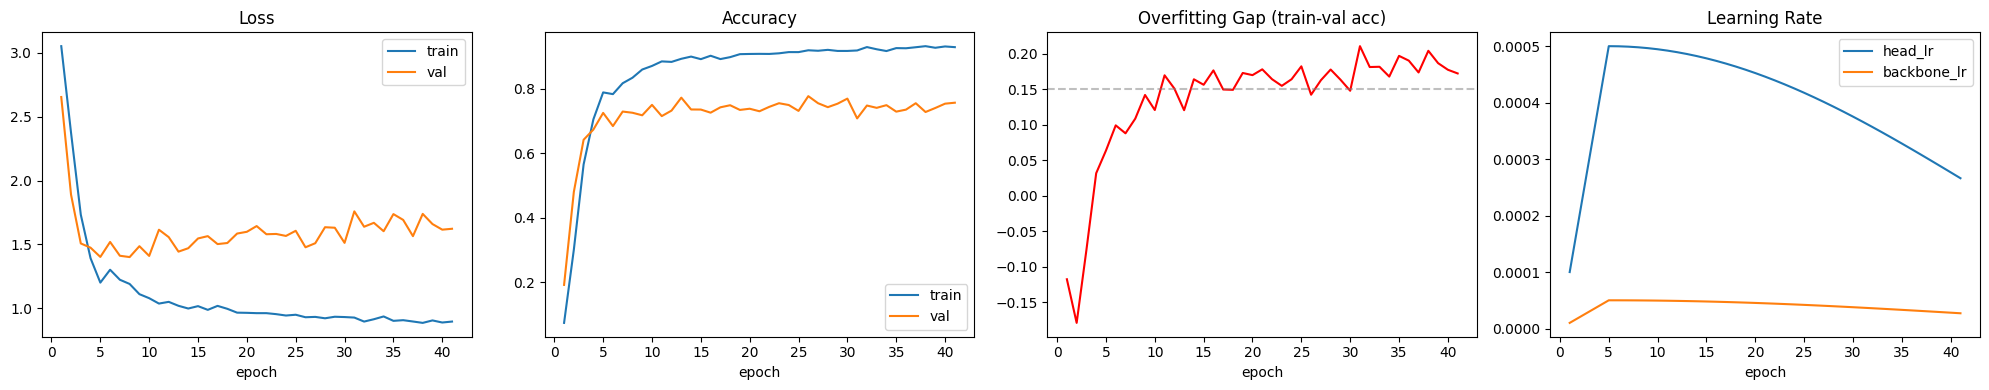

In [13]:
if not hist.empty:
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))

    axes[0].plot(hist["epoch"], hist["train_loss"], label="train")
    axes[0].plot(hist["epoch"], hist["val_loss"], label="val")
    axes[0].legend(); axes[0].set_title("Loss"); axes[0].set_xlabel("epoch")

    axes[1].plot(hist["epoch"], hist["train_acc"], label="train")
    axes[1].plot(hist["epoch"], hist["val_acc"], label="val")
    axes[1].legend(); axes[1].set_title("Accuracy"); axes[1].set_xlabel("epoch")

    axes[2].plot(hist["epoch"], hist["train_acc"] - hist["val_acc"], color="red")
    axes[2].set_title("Overfitting Gap (train-val acc)"); axes[2].set_xlabel("epoch")
    axes[2].axhline(y=0.15, color="gray", linestyle="--", alpha=0.5)

    axes[3].plot(hist["epoch"], hist["head_lr"], label="head_lr")
    axes[3].plot(hist["epoch"], hist["backbone_lr"], label="backbone_lr")
    axes[3].legend(); axes[3].set_title("Learning Rate"); axes[3].set_xlabel("epoch")

    plt.tight_layout()
    plt.show()

## 11) Best-model evaluation

/tmp/ipykernel_172904/1644537942.py:51: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


Trainable: 2,568,606 / 3,361,094


val eval: 100%|██████████| 136/136 [00:04<00:00, 32.50it/s]

Accuracy: 0.7764
Macro F1: 0.7594

Classification report:

                          precision    recall  f1-score   support

           C1_Drive_Safe     0.5976    0.6562    0.6255       224
                C2_Sleep     0.9045    0.4595    0.6094       309
              C3_Yawning     0.8624    0.8907    0.8763       183
            C4_Talk_Left     0.9142    0.9387    0.9263       261
           C5_Talk_Right     0.9362    0.6083    0.7374       217
            C6_Text_Left     0.6684    0.9034    0.7683       145
           C7_Text_Right     0.9381    0.8678    0.9016       227
              C8_Make_Up     0.7872    0.9664    0.8677       268
            C9_Look_Left     0.9750    0.8058    0.8824       242
          C10_Look_Right     0.5838    0.7063    0.6392       143
             C11_Look_Up     0.9580    0.9384    0.9481       146
           C12_Look_Down     0.5556    0.8374    0.6680       203
          C13_Smoke_Left     0.8638    0.9024    0.8827       246
         C14_Smo

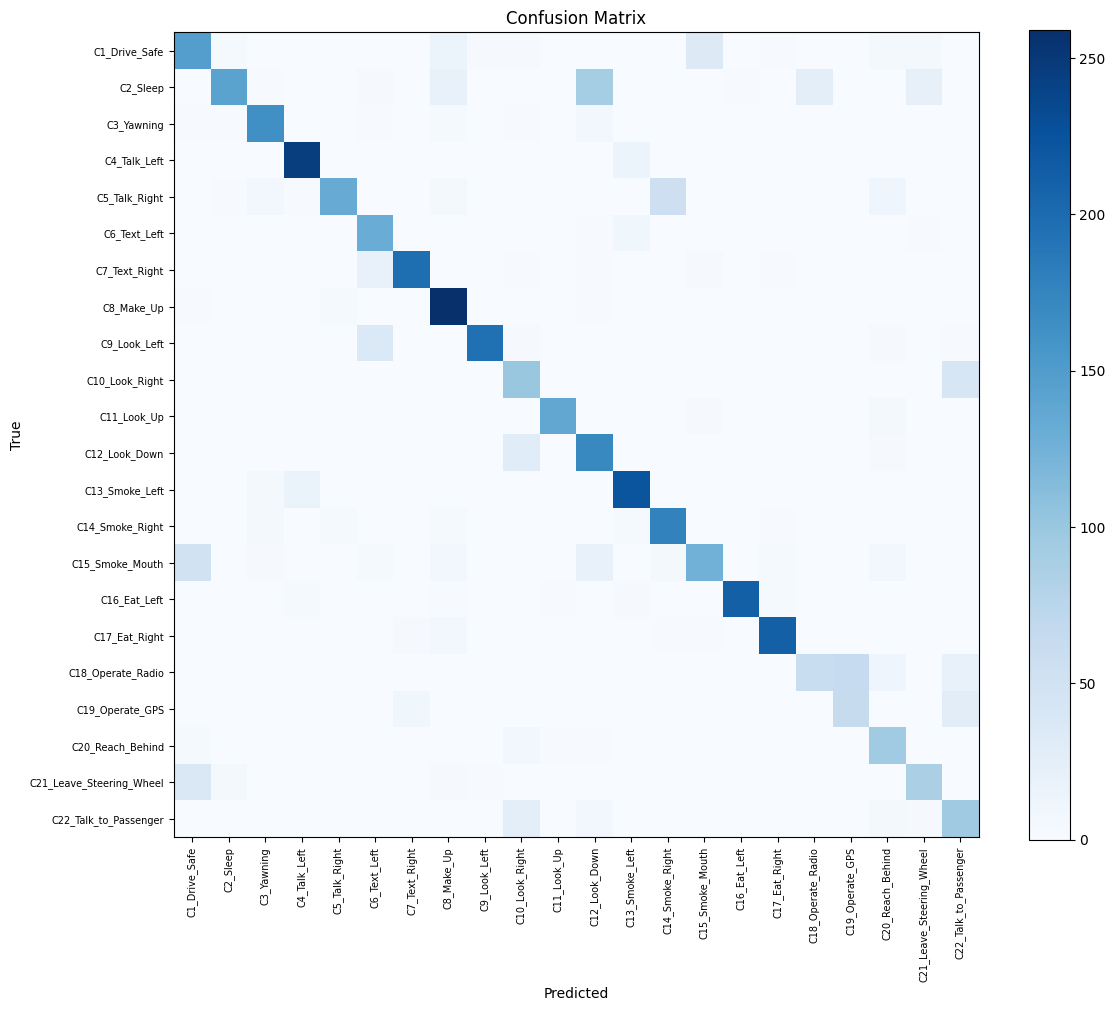

In [14]:
best_model = build_model(NUM_CLASSES, device)
state_dict = torch.load(best_path, map_location=device)
best_model.load_state_dict(state_dict)
best_model = best_model.to(device).eval()

y_true_all, y_pred_all = [], []
with torch.no_grad():
    for batch in tqdm(val_loader, desc="val eval"):
        (images, geo, gv), labels = batch
        images = images.to(device, non_blocking=True)
        geo = geo.to(device, non_blocking=True)
        gv = gv.to(device, non_blocking=True)
        logits = best_model(images, geo, gv)
        y_pred_all.append(logits.argmax(1).cpu().numpy())
        y_true_all.append(labels.numpy())

y_true_all = np.concatenate(y_true_all)
y_pred_all = np.concatenate(y_pred_all)

print(f"Accuracy: {accuracy_score(y_true_all, y_pred_all):.4f}")
print(f"Macro F1: {f1_score(y_true_all, y_pred_all, average='macro'):.4f}")
print("\nClassification report:\n")
print(classification_report(y_true_all, y_pred_all, target_names=CLASS_NAMES, digits=4))

cm = confusion_matrix(y_true_all, y_pred_all)
plt.figure(figsize=(12, 10))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
ticks = np.arange(len(CLASS_NAMES))
plt.xticks(ticks, CLASS_NAMES, rotation=90, fontsize=7)
plt.yticks(ticks, CLASS_NAMES, fontsize=7)
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

## 12) Quick inference preview

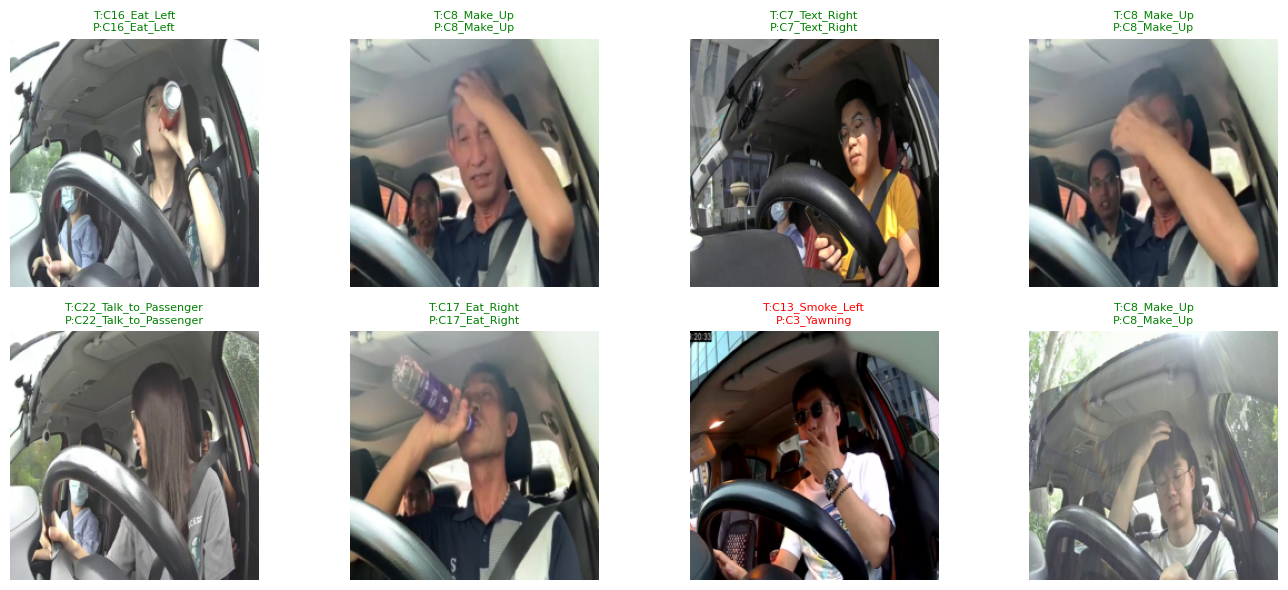

In [15]:
def denorm(x, mean, std):
    return (x * torch.tensor(std).view(3,1,1)) + torch.tensor(mean).view(3,1,1)

best_model.eval()
n = min(8, len(val_ds))
idx = np.random.choice(len(val_ds), size=n, replace=False)
samples = [val_ds[i] for i in idx]

xb = torch.stack([s[0][0] for s in samples]).to(device)
gb = torch.stack([s[0][1] for s in samples]).to(device)
gvb = torch.stack([s[0][2] for s in samples]).to(device)
yb = np.array([s[1] for s in samples])

with torch.no_grad():
    pred = best_model(xb, gb, gvb).argmax(1).cpu().numpy()

plt.figure(figsize=(14, 6))
for i in range(n):
    ax = plt.subplot(2, math.ceil(n/2), i+1)
    img = denorm(samples[i][0][0].cpu(), mean, std).clamp(0,1)
    ax.imshow(img.permute(1,2,0))
    ax.axis("off")
    color = "green" if pred[i] == yb[i] else "red"
    ax.set_title(f"T:{CLASS_NAMES[yb[i]]}\nP:{CLASS_NAMES[pred[i]]}", fontsize=8, color=color)
plt.tight_layout()
plt.show()